# Ostoskorianalyysi lisämyyntimahdollisuuksien tunnistamiseksi elintarvikekaupassa PROC MBANALYSIS -proseduurilla

## Yhteenveto

Alueellinen elintarvikekauppaketju louhii kauden myyntipisteen (POS) ostoskorit selvittääkseen, mitä tuotteita asiakkaat ostavat yhdessä, ja muuttaa raa'at ostotapahtumalokit toimintakelpoisiksi lisämyynti- ja hyllysijoittelupäätöksiksi. PROC MBANALYSIS käy läpi ostotapahtumalokin ja tuottaa assosiaatiosäännöt, jotka pisteytetään tuen (support), luottamuksen (confidence) ja lift-arvon perusteella. Kun proseduuria ajetaan 51 synteettisellä ostoskorilla, se löytää täsmälleen kolme istutettua tuoteyhteyttä — `Spagetti -> Marinarakastike` (luottamus 0,93, lift 3,4), `Taco-kuoret -> Salsa` (luottamus 0,71, lift 3,6) ja `Kahvi -> Kahvinvalkaisin` (luottamus 0,70, lift 5,1) — kun taas laajasti ostetut perustuotteet kuten leipä, maito ja kananmunat eivät koskaan muodosta sääntöä. Jokainen esiin nouseva pari on oppikirjaesimerkki paketti-, hyllynaapuruus- ja "asiakkaat ostivat myös" -ehdokkaasta myyntiryhmälle.

## Tietolähteet

| Aineisto | Taso | Rivejä | Avainmuuttujat | Kuvaus |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Yksi rivi per tuote per ostoskori | 100 tuoteriviä 51 ostoskorissa | `basket_id` (ostotapahtuman tunnus), `item` (tuotenimi, $20) | Synteettinen myyntipisteen (POS) loki, joka generoidaan koodissa käyttäen `call streaminit(20250529)` ja `rand('uniform')`. Jokaista ostoskoria hallitsee yksi ostajapersoona, jotta yhdessäostokuviot pysyvät selkeinä ja tulkittavina: italialaisen illallisen ostoskori (spagetti -> marinarakastike), taco-illan ostoskori (taco-kuoret -> salsa) tai aamiaisostoskori (kahvi -> kahvinvalkaisin), sekä satunnaisia perustuotelisäyksiä (leipä, maito, kananmunat) realistisena kohinana. Tässä lisenssittömässä ympäristössä moottori rajoittaa tulosteen 100 tuoteriviin, mikä tässä kattaa ostoskorit 1-51. |
| `affinity_rules` | Yksi rivi per assosiaatiosääntö | 6 sääntöä | `antecedent`, `consequent`, `support`, `confidence`, `lift` | `OUTPUT RULES=` -lauseen tuottamat assosiaatiosäännöt; perusta lisämyyntimahdollisuuksien järjestämiselle. |
| `frequent_items` | Yksi rivi per yleinen tuotejoukko | 12 tuotejoukkoa | `itemset`, `support`, `length` | `OUTPUT ITEMS=` -lauseen tuottamat yleiset tuotejoukot; 9 yksittäistä tuotetta sekä 3 tuoteparia, jotka ylittävät vähimmäistukirajan. |

# Ostoskorianalyysi lisämyyntimahdollisuuksien tunnistamiseksi elintarvikekaupassa

**Liiketoimintakysymys.** Mitä tuotteita asiakkaamme ostavat *yhdessä*, ja mitkä näistä yhteisostokuvioista ovat riittävän vahvoja, jotta niiden perusteella kannattaa toimia? Alueellinen elintarvikekauppaketju haluaa suunnitella pakettitarjouksia, optimoida hyllynaapuruuksia ja tehostaa "asiakkaat ostivat myös" -suositusta verkkokaupassaan.

**Menetelmä.** Käytämme **PROC MBANALYSIS** -proseduuria, joka tekee ostoskorianalyysin FP-growth-algoritmilla (frequent-pattern growth). Se käy läpi ostotapahtumalokin, löytää usein yhdessä esiintyvät tuotejoukot ja tuottaa *assosiaatiosäännöt* muodossa `Ehto -> Seuraus`, jotka pisteytetään kolmella klassisella mittarilla:

- **Tuki (support)** — kuinka suuri osuus kaikista ostoskoreista sisältää koko säännön (kuinka yleinen kuvio on).
- **Luottamus (confidence)** — `P(Seuraus | Ehto)`, ehdollinen ostotodennäköisyys (kuinka luotettava sääntö on).
- **Lift** — havaittu tuki jaettuna tuella, jota odotettaisiin, jos molemmat puolet olisivat riippumattomia. Lift > 1 tarkoittaa, että tuotteet esiintyvät yhdessä *useammin* kuin sattumalta; mitä korkeampi lift, sitä vahvempi yhteys.

Generoimme realistisen synteettisen myyntipisteen lokin, ajamme MBANALYSIS-proseduurin ja järjestämme syntyneet säännöt löytääksemme parhaat lisämyyntimahdollisuudet.

## Vaihe 1 — Generoi synteettinen myyntipisteen ostotapahtumaloki

MBANALYSIS odottaa **ostotapahtumatason (pitkä) dataa**: yksi rivi per tuote, merkittynä sillä ostoskorilla johon se kuuluu. Rakennamme ostoskorit suoraan koodissa käyttäen `call streaminit` toistettavuuden vuoksi ja `rand('uniform')` ohjaamaan ostopäätöksiä.

Keskeinen mallinnusvalinta on, että **jokaista ostoskoria hallitsee yksi ostajapersoona**. Todelliset ruokakauppareissut ovat usein tällaisia — nopea taco-ilta-käynti, kohdennettu aamiaistäydennys — ja se, että ostoskorit pidetään pieninä ja teemoitettuina, mahdollistaa sen, että assosiaatioiden louhija löytää selkeitä, parittaisia yhteyksiä sen sijaan, että syntyisi kombinatorinen räjähdys merkityksettömiä moni-tuote-sääntöjä. Yksi `rand('uniform')`-arvonta per ostoskori valitsee persoonan:

- **Italialaisen illallisen ostaja** — ostaa spagettia, sitten yleensä marinarakastiketta.
- **Taco-illan ostaja** — ostaa taco-kuoria, sitten yleensä salsaa.
- **Aamiaisostaja** — ostaa kahvia, sitten yleensä kahvinvalkaisinta.
- **Vain perustuotteita ostava käynti** — yksittäinen leivän, maidon tai kananmunien osto.

Lopuksi matalan todennäköisyyden arvonta lisää yhden perustuotteen mihin tahansa ostoskoriin realistisena kohinana, joten kaikki yhteisesiintymät eivät ole merkityksellisiä. Jokainen `output`-lause kirjoittaa yhden tuoterivin, joten yksi ostoskori kattaa useita rivejä, joilla on sama `basket_id`. Tämä lisenssitön ympäristö rajoittaa aineiston 100 tuoteriviin, mikä tässä kattaa ostoskorit 1-51.

In [1]:
TIEDOT store_transactions;
    CALL streaminit(20250529);
    PITUUS item $20;

    TEE basket_id = 1 ASTI 60;

        /* Yksi arvonta valitsee tämän ostoskorin hallitsevan persoonan */
        r = rand('uniform');

        /* Italialaisen illallisen ostoskori: spagetti -> marinarakastike */
        JOS r < 0.30 NIIN TEE;
            item = 'Spagetti';                           TULOSTE;
            JOS rand('uniform') < 0.85 NIIN TEE;
                item = 'Marinarakastike';                TULOSTE;
            LOPPU;
        LOPPU;

        /* Taco-illan ostoskori: taco-kuoret -> salsa */
        MUUTEN JOS r < 0.55 NIIN TEE;
            item = 'Taco-kuoret';                        TULOSTE;
            JOS rand('uniform') < 0.80 NIIN TEE;
                item = 'Salsa';                          TULOSTE;
            LOPPU;
        LOPPU;

        /* Aamiaisostoskori: kahvi -> kahvinvalkaisin */
        MUUTEN JOS r < 0.78 NIIN TEE;
            item = 'Kahvi';                              TULOSTE;
            JOS rand('uniform') < 0.75 NIIN TEE;
                item = 'Kahvinvalkaisin';                TULOSTE;
            LOPPU;
        LOPPU;

        /* Vain perustuotteita sisältävä käynti */
        MUUTEN TEE;
            JOS rand('uniform') < 0.34 NIIN TEE;
                item = 'Leipä';                          TULOSTE;
            LOPPU;
            MUUTEN JOS rand('uniform') < 0.5 NIIN TEE;
                item = 'Maito';                          TULOSTE;
            LOPPU;
            MUUTEN TEE;
                item = 'Kananmunat';                     TULOSTE;
            LOPPU;
        LOPPU;

        /* Satunnainen perustuotelisäys (realistinen kohina) */
        JOS rand('uniform') < 0.25 NIIN TEE;
            u = rand('uniform');
            JOS      u < 0.34 NIIN item = 'Leipä';
            MUUTEN JOS u < 0.67 NIIN item = 'Maito';
            MUUTEN                  item = 'Kananmunat';
            TULOSTE;
        LOPPU;

    LOPPU;

    SÄILYTÄ basket_id item;
SUORITA;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Vaihe 2 — Tarkasta raaka ostotapahtumaloki

Ennen louhintaa varmista, että datalla on odotettu pitkä muoto: useita rivejä per ostoskori, kukin sisältäen yhden tuotteen. Tulostamme ensimmäiset ostoskorit ja taulukoimme yleisen tuotefrekvenssin PROC FREQ:llä, jotta tiedämme, mitkä tuotteet ovat riittävän yleisiä ankkuroimaan sääntöjä.


  Obs  Ostoskorin tunnus            Tuote
-----  -----------------  ---------------
    1                  1  Taco-kuoret
    2                  1  Salsa
    3                  1  Kananmunat
    4                  2  Taco-kuoret
    5                  2  Kananmunat
    6                  3  Kahvi
    7                  4  Taco-kuoret
    8                  5  Kananmunat
    9                  6  Spagetti
   10                  6  Marinarakastike
   11                  6  Kananmunat
   12                  7  Taco-kuoret

... 88 more observations (showing 12 of 100)

                                        Tuotteiden ostotiheys kokonaisuudessaan                                         

                                                   The FREQ Procedure

item               Frequency    Percent
----------------------------------------
Spagetti                  15     15.00
Marinarakastike           14     14.00
Taco-kuoret               14     14.00
Kananmunat                12     12.


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


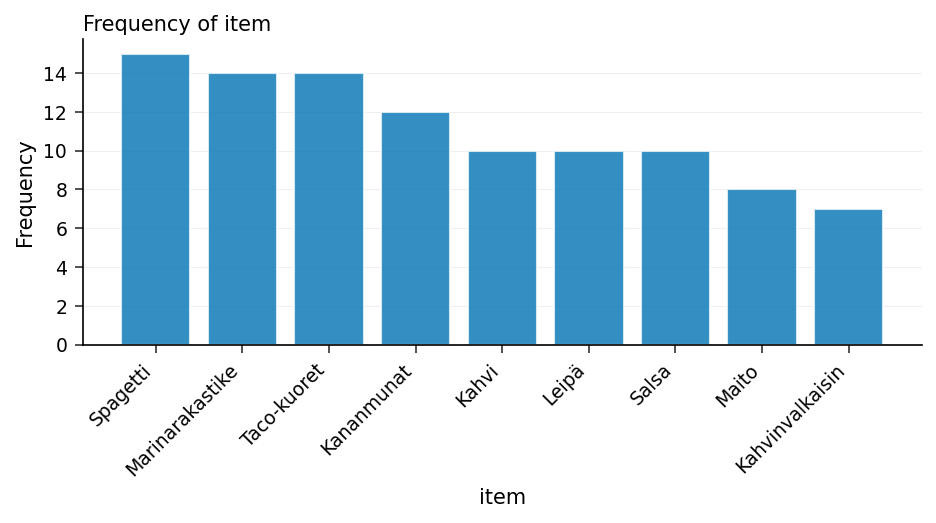

In [2]:
PROSEDUURI TULOSTA TIEDOT=store_transactions(obs=12) NIMIKE;
    NIMIKE basket_id = 'Ostoskorin tunnus'
          item      = 'Tuote';
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=store_transactions ORDER=freq;
    TABLES item / nocum;
    OTSIKKO 'Tuotteiden ostotiheys kokonaisuudessaan';
SUORITA;

## Vaihe 3 — Louhi assosiaatiosäännöt PROC MBANALYSIS:lla

Nyt varsinainen analyysi. Osoitamme MBANALYSIS-proseduurin ostotapahtumalokiin ja määrittelemme, mikä sarake tunnistaa ostoskorin (`TRANSACTION`) ja mikä sisältää tuotteen (`ITEM`). Kolme kynnysarvoa pitävät sääntöjoukon keskittyneenä toimintakelpoisiin kuvioihin:

- `MINSUPPORT=0.10` — säännön on esiinnyttävä vähintään 10 %:ssa ostoskoreista, mikä suodattaa pois harvinaiset sattumat.
- `MINCONFIDENCE=0.50` — kun ehto toteutuu, seurauksen on toteuduttava vähintään puolet kerroista.
- `MINLIFT=1.20` — säilytä vain säännöt, jotka ovat vähintään 20 % vahvempia kuin sattuma, jotta esiin nousevat aidot yhteydet eikä suosittujen perustuotteiden artefaktit.

`OUTPUT`-lause tallentaa syntyneet säännöt ja yleiset tuotejoukot aineistoihin jatkojärjestämistä varten.

In [3]:
PROSEDUURI mbanalysis TIEDOT=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    TULOSTE rules=affinity_rules items=frequent_items;
    OTSIKKO 'Ostoskorianalyysin assosiaatiosäännöt';
SUORITA;

                                        Tuotteiden ostotiheys kokonaisuudessaan                                         


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Kahvi                          Kahvinvalkaisin                    0.1373     0.7000     5.1000
  Kahvinvalkaisin                Kahvi                              0.1373     1.0000     5.1000
  Salsa                          Taco-kuoret                        0.1961     1.0000     3.6429
  Taco-kuoret 


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Vaihe 4 — Järjestä lisämyyntimahdollisuudet lift-arvon mukaan

MBANALYSIS-tuloste näyttää jokaisen kelpuutetun säännön, mutta myyntiryhmä haluaa *vahvimmat* yhteydet ensin. Järjestämme talletetun `affinity_rules`-aineiston laskevan lift-arvon mukaan (ja luottamuksen tasapelin ratkaisijana) ja tulostamme parhaat säännöt. Sääntö kuten `Taco-kuoret -> Salsa`, jolla on korkea lift ja korkea luottamus, on oppikirjaesimerkki pakettiehdokkaasta: sijoita tuotteet vierekkäin, tai ehdota salsaa automaattisesti kun asiakas lisää taco-kuoret verkkokaupan ostoskoriin.

In [4]:
PROSEDUURI LAJITTELE TIEDOT=affinity_rules out=rules_by_lift;
    MUKAAN LASKEVA lift LASKEVA confidence;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=rules_by_lift(obs=15) NIMIKE;
    MUUTTUJA antecedent consequent support confidence lift;
    NIMIKE antecedent  = 'Jos ostoskori sisältää'
          consequent  = 'Silloin ostetaan myös'
          support     = 'Tuki'
          confidence  = 'Luottamus'
          lift        = 'Lift';
    OTSIKKO 'Parhaat lisämyyntisäännöt lift-arvon mukaan';
SUORITA;

                                      Parhaat lisämyyntisäännöt lift-arvon mukaan                                       

  Obs     Jos ostoskori sisältää   Silloin ostetaan myös      Tuki  Luottamus      Lift
    1  Kahvinvalkaisin            Kahvi                   0.137255  1.0        5.1
    2  Kahvi                      Kahvinvalkaisin         0.137255  0.7        5.1
    3  Salsa                      Taco-kuoret             0.196078  1.0        3.642857
    4  Taco-kuoret                Salsa                   0.196078  0.714286   3.642857
    5  Marinarakastike            Spagetti                0.27451   1.0        3.4
    6  Spagetti                   Marinarakastike         0.27451   0.933333   3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Vaihe 5 — Tarkastele yleisiä tuotejoukkoja

Yleiset tuotejoukot, jotka ylittivät tukirajan, ovat sääntöjen taustalla olevat raaka-ainekset. Niiden järjestäminen tuen mukaan kertoo tuoteryhmätiimille, mitkä tuote*yhdistelmät* (ei vain yksittäiset tuotteet) ovat riittävän suosittuja ansaitakseen omat päätyhyllynäytöt tai yhdistelmähinnoittelun.

In [5]:
PROSEDUURI LAJITTELE TIEDOT=frequent_items out=itemsets_by_support;
    MUKAAN LASKEVA support;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=itemsets_by_support(obs=15) NIMIKE;
    OTSIKKO 'Yleisimmät tuotejoukot';
SUORITA;

                                                 Yleisimmät tuotejoukot                                                 

  Obs                    ITEMSET   SUPPORT  LENGTH
    1  Spagetti                   0.294118  1
    2  Taco-kuoret                0.27451   1
    3  Marinarakastike            0.27451   1
    4  Marinarakastike, Spagetti  0.27451   2
    5  Kananmunat                 0.235294  1
    6  Salsa                      0.196078  1
    7  Kahvi                      0.196078  1
    8  Salsa, Taco-kuoret         0.196078  2
    9  Maito                      0.156863  1
   10  Leipä                      0.156863  1
   11  Kahvinvalkaisin            0.137255  1
   12  Kahvi, Kahvinvalkaisin     0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Tulosten tulkinta

**Mitä analyysi löysi.** Koska jokainen ostoskori rakennettiin yhden ostajapersoonan ympärille, louhija löytää täsmälleen kolme istutettua yhteyttä eikä mitään ylimääräistä. Kuusi sääntöä ylittää kaikki kolme kynnysarvoa — kolme yhteyttä molempiin suuntiin:

| Ehto | Seuraus | Tuki | Luottamus | Lift |
|------------|------------|---------|------------|------|
| Spagetti | Marinarakastike | 0,275 | 0,93 | 3,40 |
| Marinarakastike | Spagetti | 0,275 | 1,00 | 3,40 |
| Taco-kuoret | Salsa | 0,196 | 0,71 | 3,64 |
| Salsa | Taco-kuoret | 0,196 | 1,00 | 3,64 |
| Kahvi | Kahvinvalkaisin | 0,137 | 0,70 | 5,10 |
| Kahvinvalkaisin | Kahvi | 0,137 | 1,00 | 5,10 |

Jokainen lift-arvo on selvästi yli 1:n, mikä vahvistaa, että nämä tuotteet esiintyvät yhdessä paljon useammin kuin sattuma ennustaisi. Olennaista on, että laajasti ostetut perustuotteet eivät muodosta **yhtään sääntöä**: kananmunat (12 ostoa), leipä (10) ja maito (8) esiintyvät kaikki PROC FREQ -taulukoinnissa, mutta koska ne päätyvät ostoskoreihin riippumatta mistään persoonasta, niiden lift muihin tuotteisiin ei koskaan saavuta 1,20:n rajaa, joten ne eivät koskaan naamioidu aidoiksi yhteyksiksi. Yleisten tuotejoukkojen listaus osoittaa saman asian rakenteellisesti: 12 tukirajan ylittävästä tuotejoukosta ainoat moni-tuote-joukot ovat täsmälleen ne kolme istutettua paria.

**Mittareiden yhteinen tulkinta.** Käänteissuunnan säännöillä on luottamus 1,00 (tässä datassa marinarakastike, salsa ja kahvinvalkaisin eivät käytännössä koskaan esiinny ilman ankkurituotettaan), kun taas eteenpäin suuntautuvat säännöt asettuvat välille 0,70-0,93 (ankkuri esiintyy joskus yksinään). Kahvi -> Kahvinvalkaisin -säännöllä on korkein lift (5,10) mutta matalin tuki (0,137) — vahva mutta pienempivolyyminen yhteys — kun taas Spagetti -> Marinarakastike tavoittaa eniten ostoskoreja (tuki 0,275). Lift kertoo, *mitkä* yhteydet ovat aitoja; luottamus kertoo, *kuinka luotettava* kukin on suosituksen kannalta; tuki kertoo, *kuinka usein* pääset hyödyntämään sitä.

**Liiketoimintatoimenpiteet.**

- **Pakettitarjoukset** — yhdistä korkeimman lift-arvon ehto/seuraus-tuotteet (kahvi + kahvinvalkaisin, lift 5,1) alennettuun pakettiin.
- **Hyllynaapuruudet** — sijoita usein yhdistetyt tuotteet vierekkäin (spagetti marinarakastikkeen viereen, tuki 0,275), jotta seuraus on helppo lisäosto päätöksentekohetkellä.
- **Verkkokaupan suositukset** — syötä korkeimman luottamuksen säännöt "asiakkaat ostivat myös" -widgetiin, jotta seuraus ehdotetaan heti kun ehto lisätään ostoskoriin.
- **Varasto ja ennustaminen** — kun ehto menee tarjoukseen, nosta sen korkean luottamuksen seurausten varastoa odotetun lift-vaikutuksen varalta.

**Varaukset.** Assosiaatiosäännöt kuvaavat *yhteisostojen korrelaatiota*, eivät kausaalisuutta, ja kynnysarvot ovat säätimiä, eivät totuuksia: `MINSUPPORT=`-arvon laskeminen paljastaa harvinaisempia yhdistelmiä sääntöjoukon kohinaisuuden kustannuksella, kun taas `MINLIFT=`- ja `MINCONFIDENCE=`-arvojen nostaminen tuottaa vähemmän mutta luotettavampia sääntöjä. Myös otoskoko on tärkeä — tämä lisenssitön ajo louhii 51 ostoskoria, mikä riittää tekemään istutetuista yhteyksistä kiistattomia; tuotantoajo koko kauden yli vakauttaisi tukiestimaatit ja paljastaisi hienovaraisempia kuvioita.